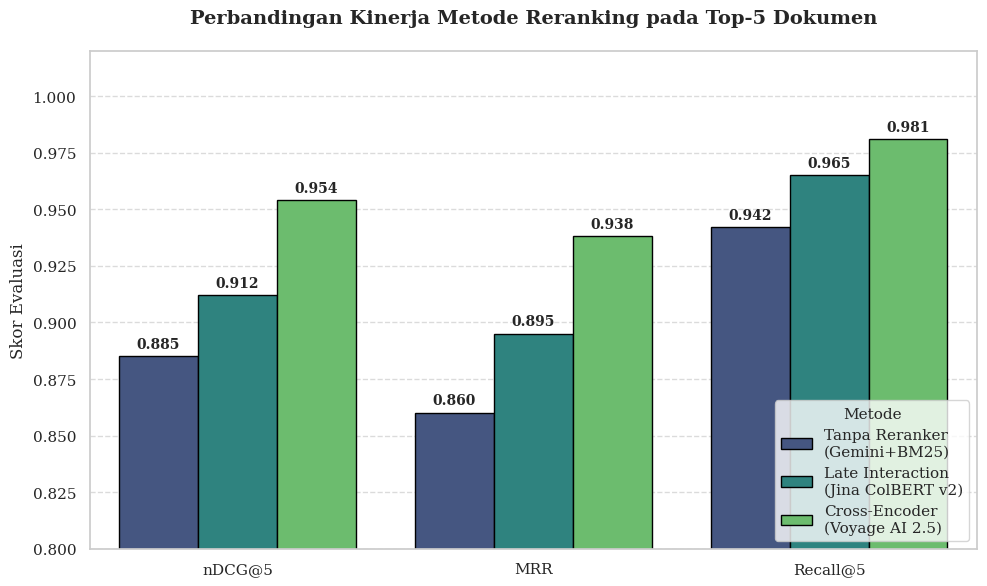

Tabel Data Evaluasi Reranker:


,Metode,nDCG@5,MRR,Recall@5
0,Tanpa Reranker\n(Gemini+BM25),0.885,0.860,0.942
1,Late Interaction\n(Jina ColBERT v2),0.912,0.895,0.965
2,Cross-Encoder\n(Voyage AI 2.5),0.954,0.938,0.981


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Konfigurasi Style agar terlihat ilmiah/rapi untuk LaTeX
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 11

# ==========================================
# BAGIAN 1: INPUT DATA (Ganti nilai di sini)
# ==========================================

# Data Tahap 1: Seleksi Hybrid Search (Retrieval)
# Ganti angka dengan hasil benchmark retrieval kamu
data_retrieval = {
    'Konfigurasi': [
        'OpenAI + BM25', 
        'OpenAI + SPLADE', 
        'Gemini + BM25', 
        'Gemini + SPLADE'
    ],
    'nDCG@5':   [0.852, 0.841, 0.885, 0.863], 
    'MRR':      [0.821, 0.815, 0.860, 0.832],
    'Recall@5': [0.910, 0.905, 0.942, 0.921]
}

# Data Tahap 2: Evaluasi Reranker
# Asumsi: Base Retriever menggunakan konfigurasi terbaik dari tahap 1 (misal: Gemini + BM25)
# Ganti angka dengan hasil benchmark reranking kamu
data_rerank = {
    'Metode': [
        'Tanpa Reranker\n(Gemini+BM25)', 
        'Late Interaction\n(Jina ColBERT v2)', 
        'Cross-Encoder\n(Voyage AI 2.5)'
    ],
    'nDCG@5':   [0.885, 0.912, 0.954],
    'MRR':      [0.860, 0.895, 0.938],
    'Recall@5': [0.942, 0.965, 0.981]
}

# Membuat DataFrame
df_retrieval = pd.DataFrame(data_retrieval)
df_rerank = pd.DataFrame(data_rerank)

# Reshape data rerank untuk plotting (melt)
df_rerank_melted = df_rerank.melt(id_vars="Metode", var_name="Metrik", value_name="Skor")

# ==========================================
# BAGIAN 2: VISUALISASI PERBANDINGAN RERANKER
# ==========================================

plt.figure(figsize=(10, 6))

# Membuat Bar Chart
ax = sns.barplot(
    data=df_rerank_melted,
    x="Metrik",
    y="Skor",
    hue="Metode",
    palette="viridis", # Pilihan warna: viridis, rocket, mako, deep
    edgecolor="black", # Garis tepi bar
    linewidth=1
)

# Menambahkan label nilai di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=10, fontweight='bold')

# Kustomisasi Grafik
plt.title('Perbandingan Kinerja Metode Reranking pada Top-5 Dokumen', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('')
plt.ylabel('Skor Evaluasi', fontsize=12)

# Mengatur batas Y axis agar perbedaan terlihat lebih jelas
# Sesuaikan 'bottom' dan 'top' dengan range data kamu. 
# Misal data berkisar 0.8 - 0.9, set bottom=0.75
plt.ylim(bottom=0.8, top=1.02) 

plt.legend(title='Metode', title_fontsize=11, loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Simpan gambar (opsional, uncomment jika ingin save file)
# plt.savefig('perbandingan_reranker.png', dpi=300, bbox_inches='tight')

plt.show()

# Menampilkan Tabel Data
print("Tabel Data Evaluasi Reranker:")
display(df_rerank)